# AIoT Project
## Time Series

This notebook is the entry point for the Time Series analysis pipeline.

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [6]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


## Load data

The documents that correspond to the **IMU HAND AccGyr sensor configuration**. 



In [7]:
query = {"split":"Protocol", "imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))


In [8]:
df_segments = pd.DataFrame(documents)

print(df_segments.columns)

Index(['_id', 'data', 'activity_id', 'activity_label', 'subject', 'split',
       'imu_location', 'sensor', 'sr', 'datetime'],
      dtype='str')


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

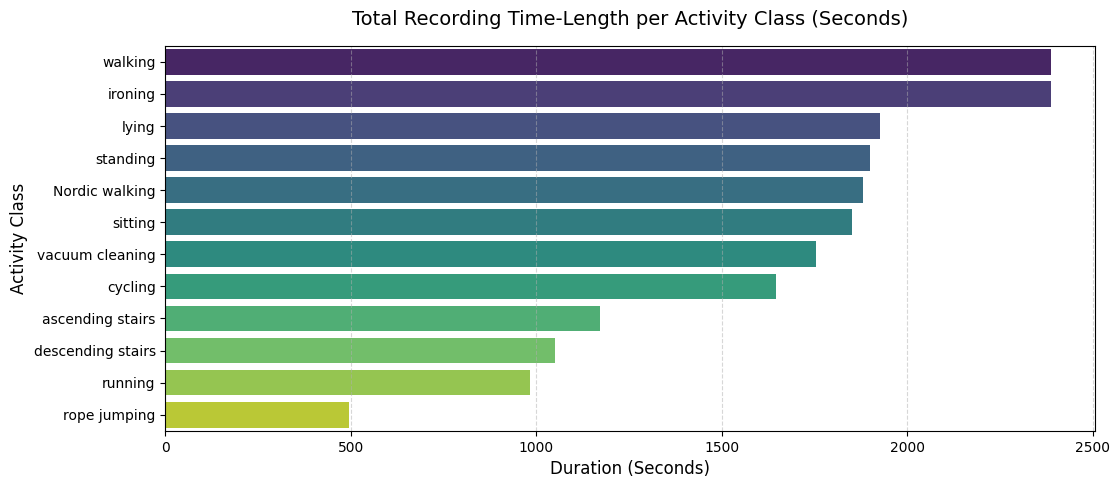

In [9]:
df_segments['num_samples'] = df_segments['data'].apply(lambda x: len(x['acc_x']))
df_segments['duration_seconds'] = df_segments['num_samples'] / 100.0

activity_time = df_segments.groupby('activity_label')['duration_seconds'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=activity_time.values, y=activity_time.index, hue=activity_time.index, palette='viridis', legend=False)
plt.title('Total Recording Time-Length per Activity Class (Seconds)', fontsize=14, pad=15)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Activity Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


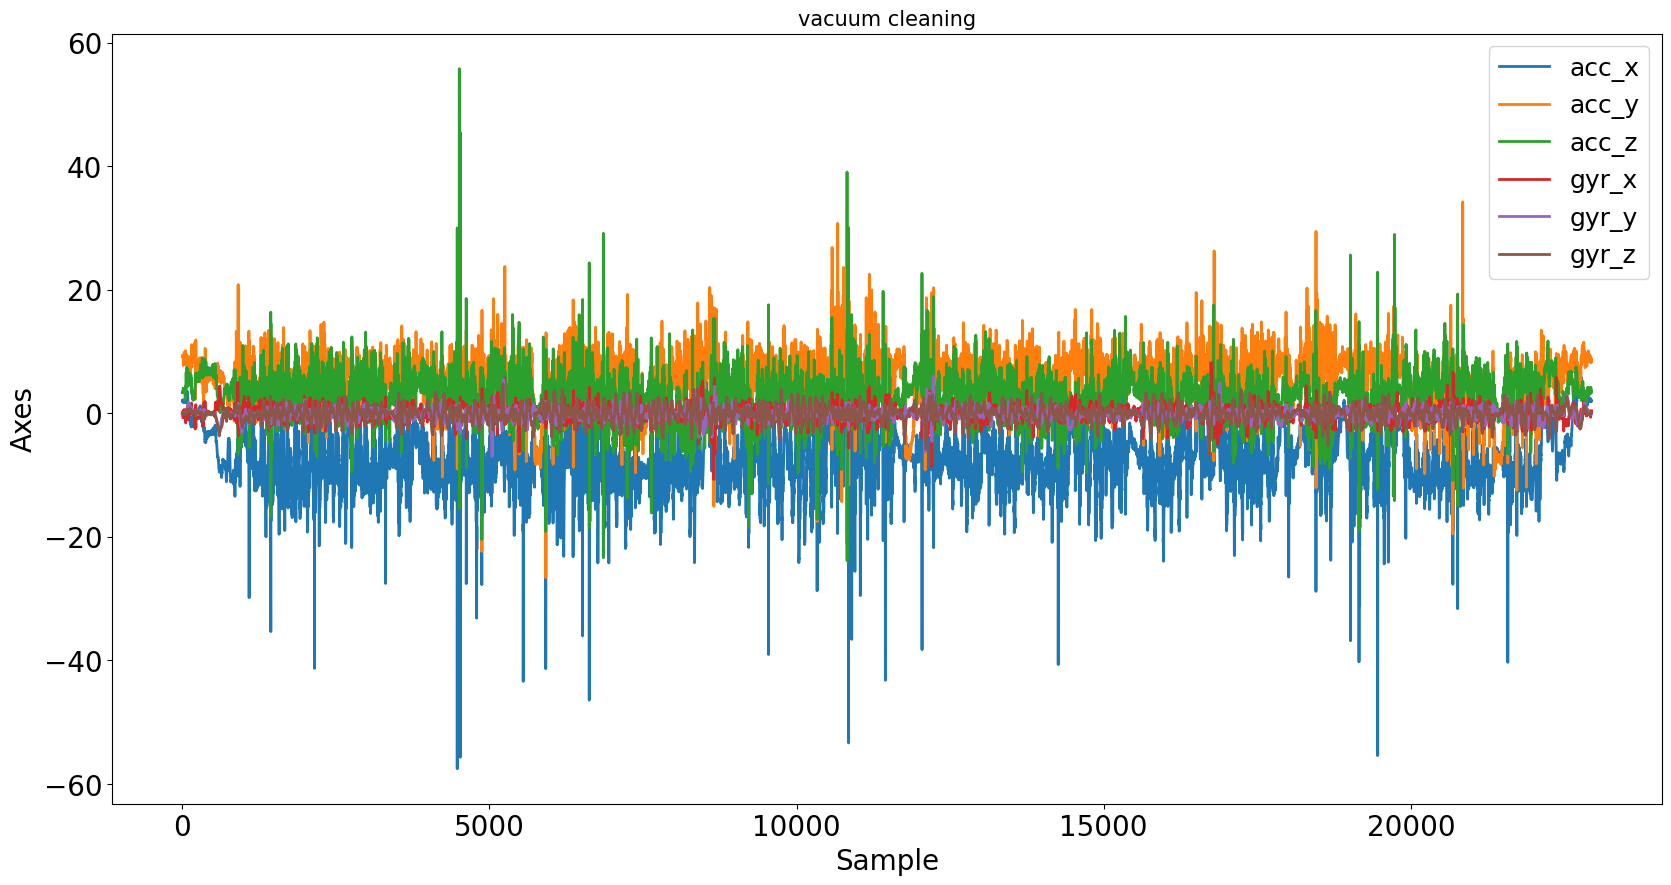

In [10]:
print (found_labels)
sample = df_segments[df_segments['activity_label'] == 'vacuum cleaning'].iloc[0]

sample_signal_df = pd.DataFrame(dict(sample['data']))

plot_instance_time_domain(sample_signal_df)
plt.title(f"{sample['activity_label']}", fontsize=15)
plt.show()

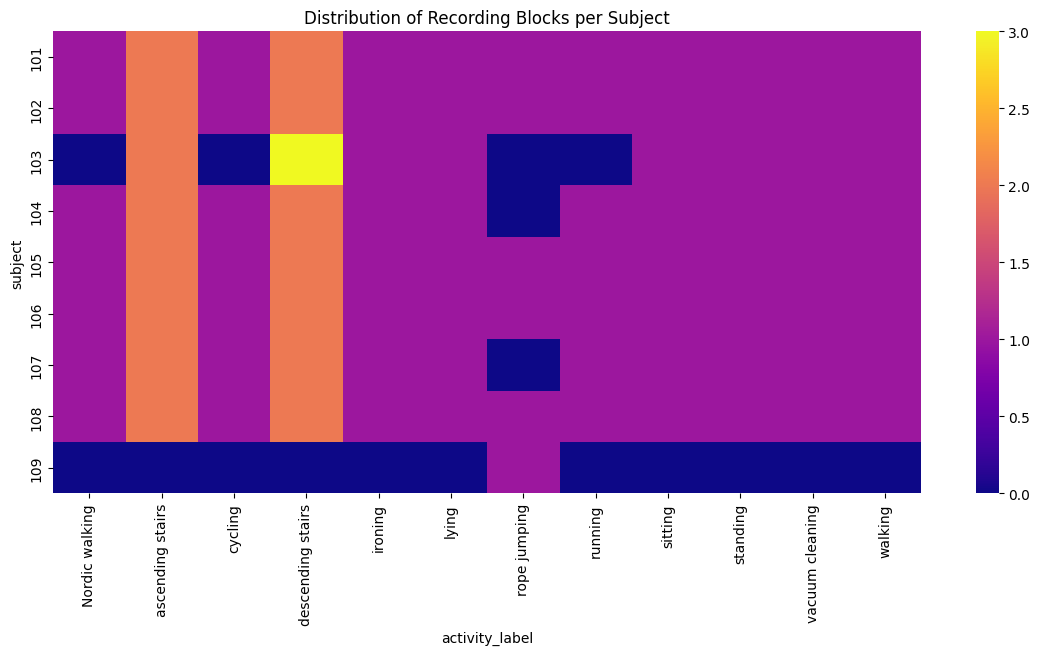

In [11]:
imbalance_matrix = pd.crosstab(df_segments['subject'], df_segments['activity_label'])

plot_heatmap(imbalance_matrix)
plt.title("Distribution of Recording Blocks per Subject")
plt.show()

## Data Processing
Train & Test Split And Windowing

In [12]:
TRAIN_SUBJECTS = ["101", "102", "103", "104", "105", "107"]
TEST_SUBJECTS  = ["106", "108", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

train_segments = df_segments[df_segments["subject"].astype(str).isin(TRAIN_SUBJECTS)]
test_segments  = df_segments[df_segments["subject"].astype(str).isin(TEST_SUBJECTS)]

from utils import make_pairs


training_windowpairs = make_pairs(train_segments,config)
test_windowpairs     = make_pairs(test_segments,config)



print(f"Train segments: {len(train_segments)}")
print(f"Test segments:  {len(test_segments)}")

print(f"Total window instances generated across training_subject segments: {len(training_windowpairs)}")
print(f"Total window instances generated across test_subject segments: {len(test_windowpairs)}")
print(f"Total window instances generated across both training and test segments: {len(training_windowpairs) + len(test_windowpairs)}")

Train segments: 79
Test segments:  29
Total window instances generated across training_subject segments: 4000
Total window instances generated across test_subject segments: 1379
Total window instances generated across both training and test segments: 5379


In [13]:
from utils import filter_pairs

filtered_training_list = filter_pairs(training_windowpairs, config)
filtered_test_list     = filter_pairs(test_windowpairs, config)

print(f"Filtered train windows : {len(filtered_training_list)}")
print(f"Filtered test windows  : {len(filtered_test_list)}")


Filtered train windows : 4000
Filtered test windows  : 1379


# Inspection of Windowed Signals Before Filtering and After Filterring

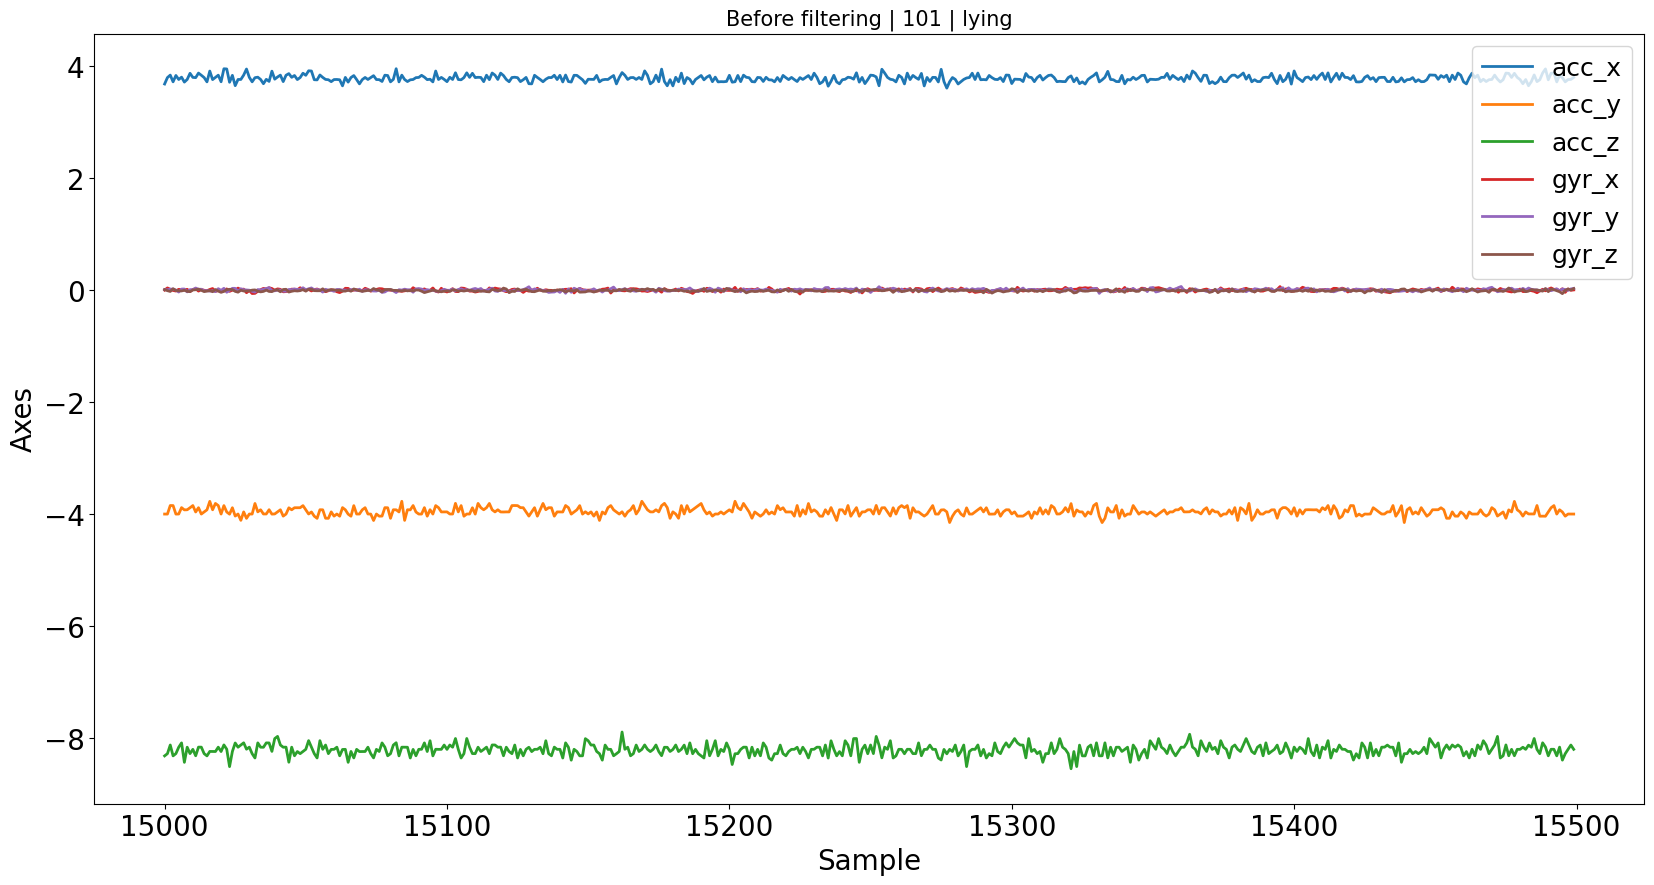

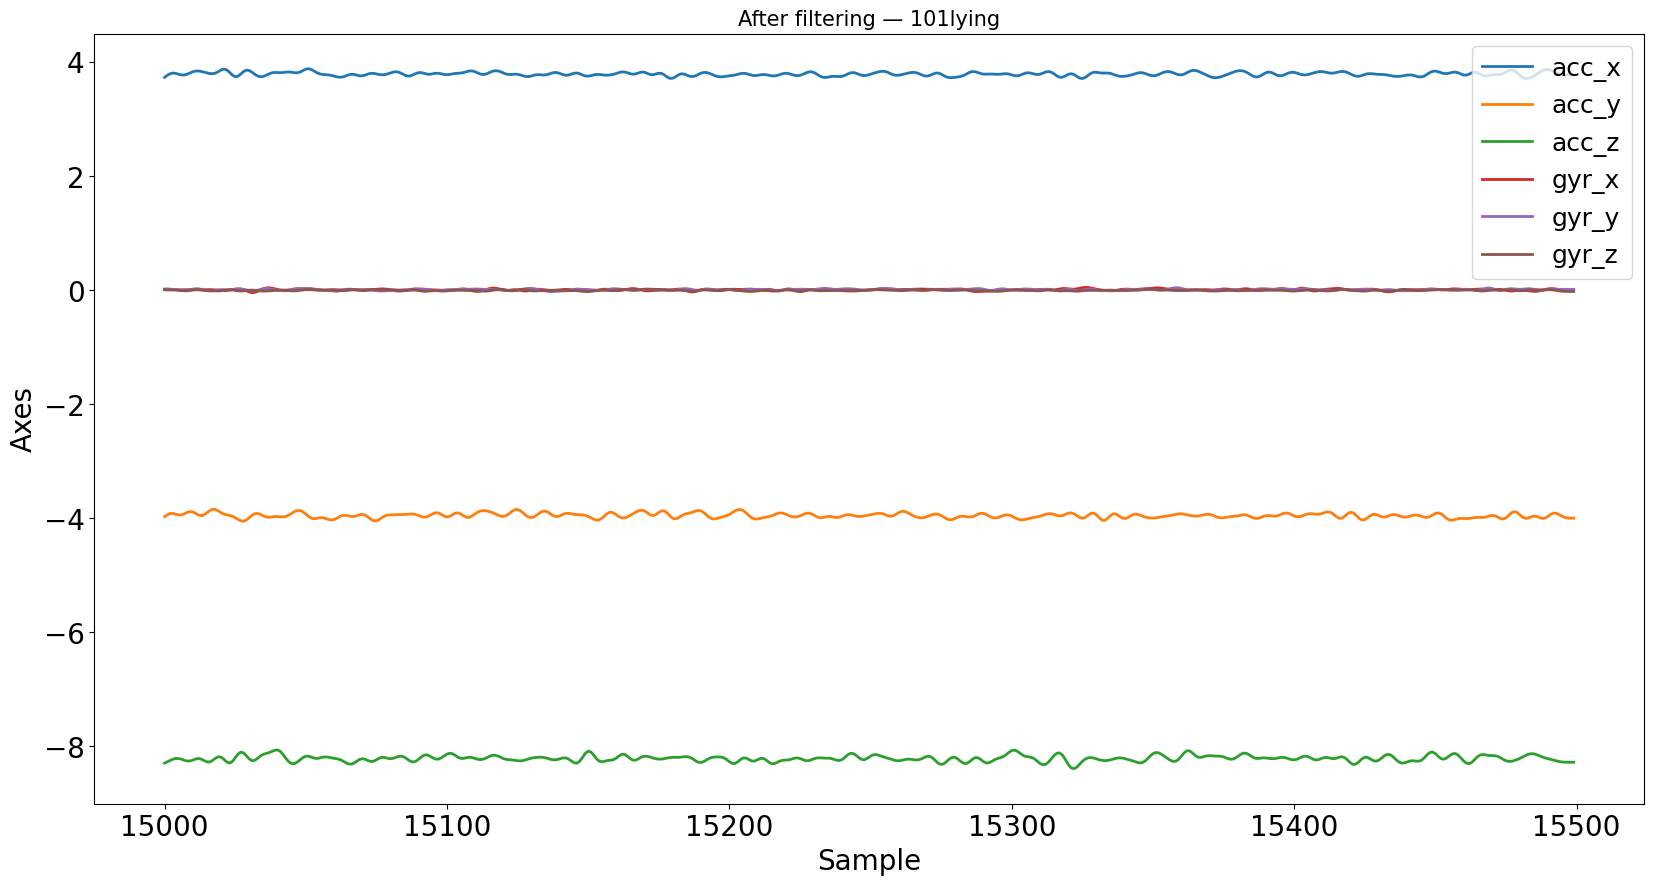

In [14]:
i = 60 # change to inspect different windows
# Before

plot_instance_time_domain(training_windowpairs[i]['window'])
plt.title(f"Before filtering | {training_windowpairs[i]['subject']} | {training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_training_list[i])
plt.title(f"After filtering — {training_windowpairs[i]['subject']}{training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()



# Same for Test Subjects

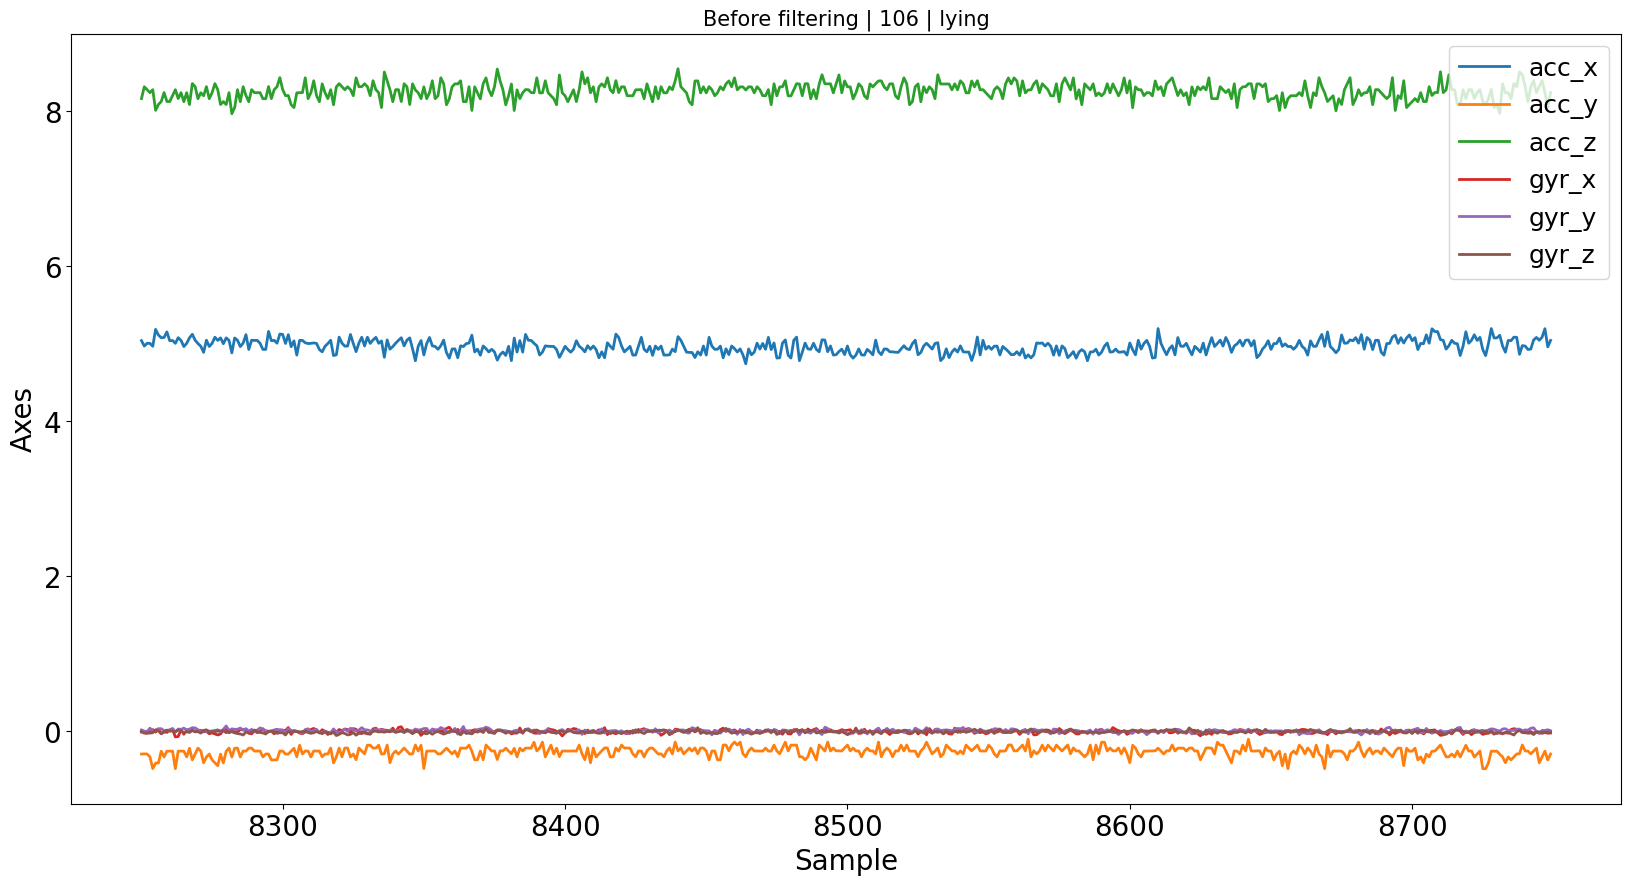

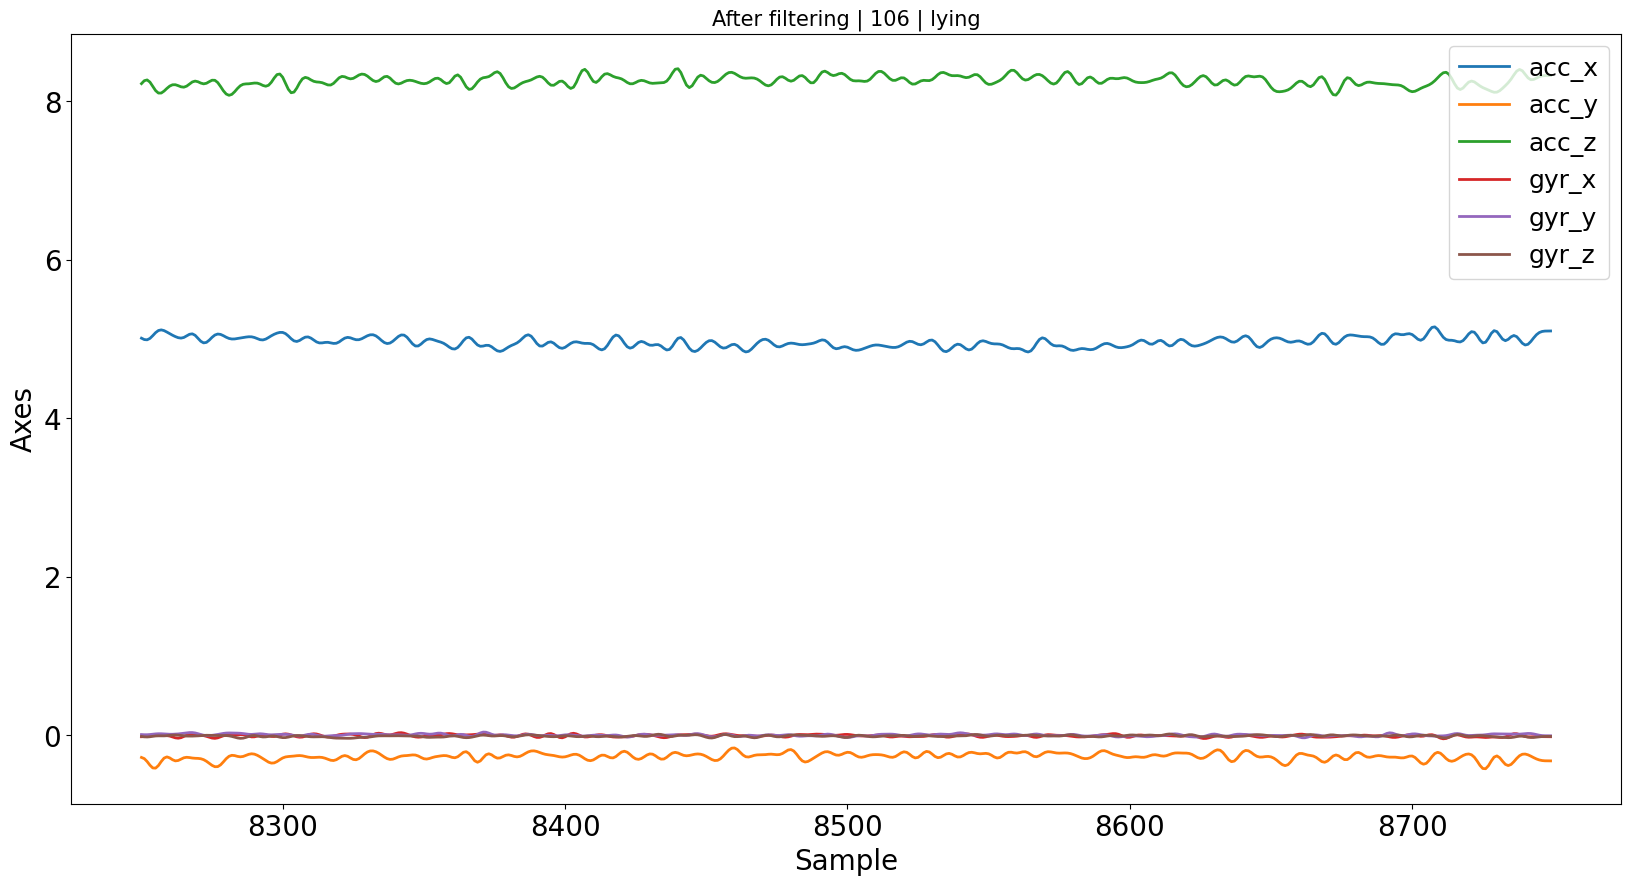

In [15]:
i = 30 # change to inspect different windows
# Before

plot_instance_time_domain(test_windowpairs[i]['window'])
plt.title(f"Before filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_test_list[i])
plt.title(f"After filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()



# NaN Values Check

In [16]:
# ── NaN check after filtering ────────────────────────────────────────────────
nan_train = sum(df.isnull().values.any() for df in filtered_training_list)
nan_test  = sum(df.isnull().values.any() for df in filtered_test_list)

print(f"Train windows with NaN: {nan_train} / {len(filtered_training_list)}")
print(f"Test windows with NaN:  {nan_test}  / {len(filtered_test_list)}")

assert nan_train == 0, "NaN values found in training set!"
assert nan_test  == 0, "NaN values found in test set!"

print(" No NaN values found —")

Train windows with NaN: 0 / 4000
Test windows with NaN:  0  / 1379
 No NaN values found —


# Scaling
We fit `StandardScaler` on training data only, then transform both train and test sets. Fitting on test data would constitute **Scaler Leakage** — the test statistics would influence normalisation and inflate reported metrics.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from utils import flatten_instances_df, encode_labels

X_train = flatten_instances_df(filtered_training_list).to_numpy()
X_test  = flatten_instances_df(filtered_test_list).to_numpy()

y_train = encode_labels([p["activity_label"] for p in training_windowpairs])
y_test  = encode_labels([p["activity_label"] for p in test_windowpairs])

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

X_train: (4000, 3000) | y_train: (4000,)
X_test:  (1379, 3000)  | y_test:  (1379,)


## Classifier - Statistical Learning

### Apply simple classifier

In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Get class names
le = LabelEncoder()
le.fit([p["activity_label"] for p in training_windowpairs])
class_names = le.classes_

#  Train SVM from config 
svm = SVC(
    C=config["classifier"]["SVC"]["C"],
    kernel=config["classifier"]["SVC"]["kernel"],
    gamma=config["classifier"]["SVC"]["gamma"],
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Train Random Forest from config
rf = RandomForestClassifier(
    max_depth=config["classifier_2"]["RFC"]["max_depth"],
    max_features=config["classifier_2"]["RFC"]["max_features"],
    n_estimators=config["classifier_2"]["RFC"]["n_estimators"],
    random_state=config["classifier_2"]["RFC"]["random_state"],
    n_jobs=config["classifier_2"]["RFC"]["n_jobs"]
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Reports 
print("=" * 50)
print("SVM"); print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=class_names, zero_division=0))

print("=" * 50)
print("Random Forest"); print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=class_names, zero_division=0))



SVM
                   precision    recall  f1-score   support

   Nordic walking       0.96      0.52      0.68        88
 ascending stairs       0.76      0.76      0.76        92
          cycling       0.46      0.74      0.57       165
descending stairs       0.58      0.58      0.58        72
          ironing       0.58      0.29      0.39       228
            lying       0.80      0.96      0.87       179
     rope jumping       0.00      0.00      0.00        30
          running       0.00      0.00      0.00        25
          sitting       0.65      0.66      0.65       163
         standing       0.83      0.42      0.56       160
  vacuum cleaning       0.29      0.64      0.40       138
          walking       0.96      0.59      0.73        39

         accuracy                           0.58      1379
        macro avg       0.57      0.51      0.52      1379
     weighted avg       0.63      0.58      0.57      1379

Random Forest
                   precision    rec

SVM Confusion Matrix


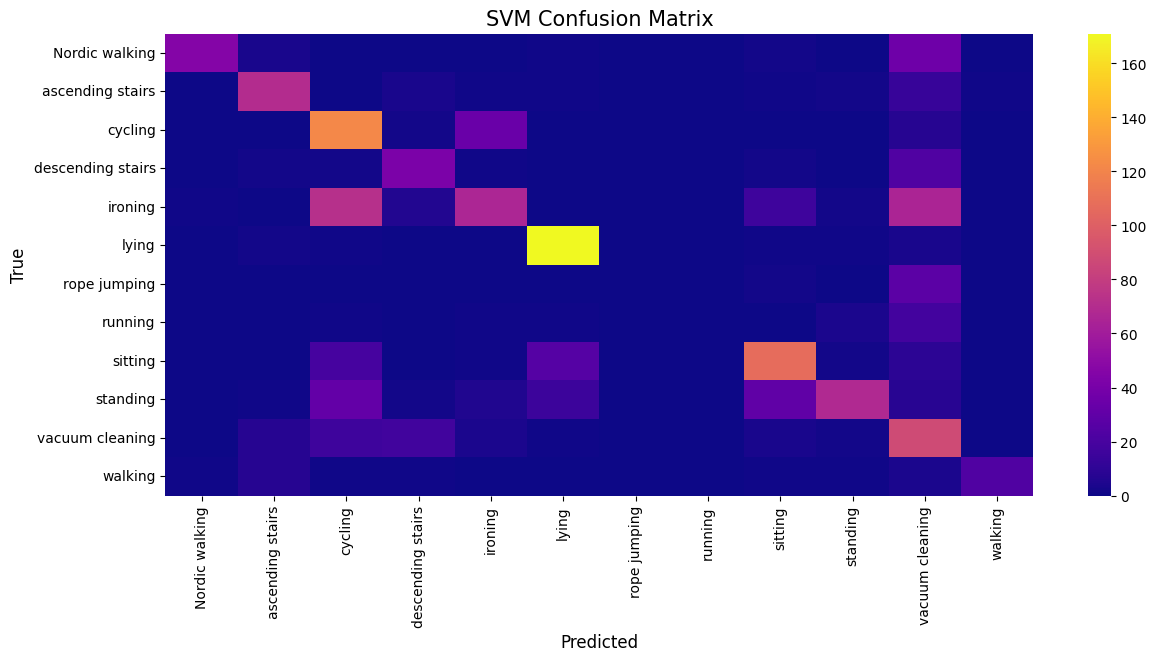

Random Forest Confusion Matrix


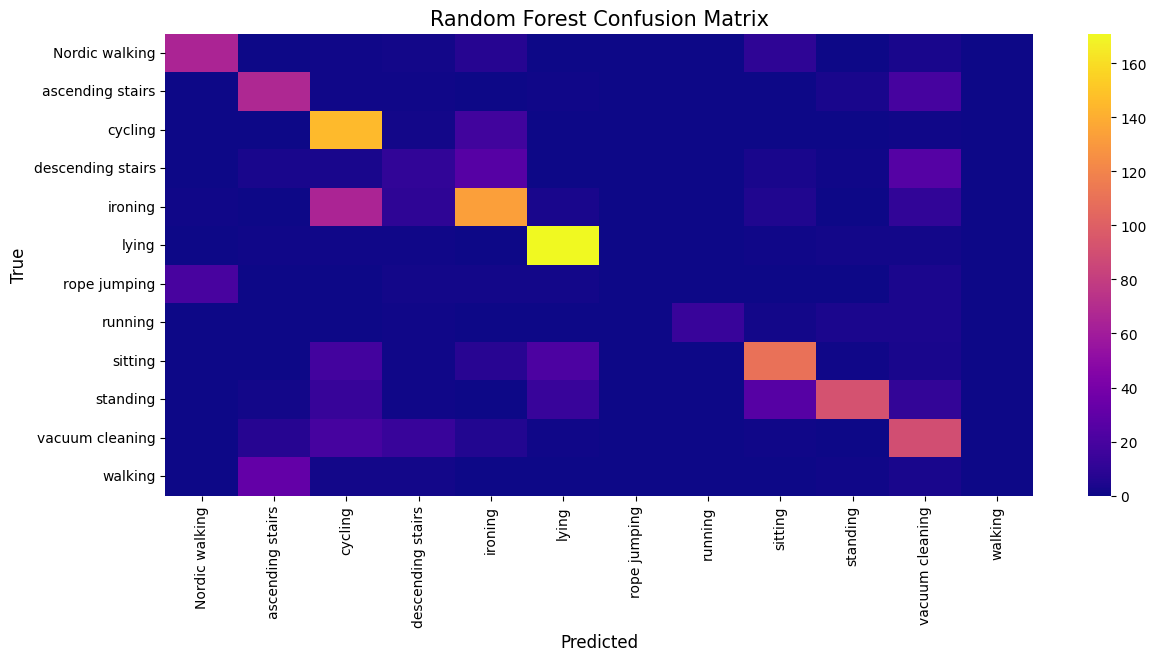

In [19]:
from utils_visual import plot_heatmap
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit([p["activity_label"] for p in training_windowpairs])
class_names = le.classes_

# SVM Confusion Matrix
cm_svm = pd.DataFrame(
    confusion_matrix(y_test, y_pred_svm),
    index=class_names,
    columns=class_names
)
print("SVM Confusion Matrix")
plot_heatmap(cm_svm)
plt.title("SVM Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.show()

# Random Forest Confusion Matrix 
cm_rf = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf),
    index=class_names,
    columns=class_names
)
print("Random Forest Confusion Matrix")
plot_heatmap(cm_rf)
plt.title("Random Forest Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.show()

### Evaluate simple classifier

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
print("=" * 50)
print("SVM Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=class_names, zero_division=0))


print("=" * 50)
print("Random Forest Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=class_names, zero_division=0))



SVM Classification Report
                   precision    recall  f1-score   support

   Nordic walking       0.96      0.52      0.68        88
 ascending stairs       0.76      0.76      0.76        92
          cycling       0.46      0.74      0.57       165
descending stairs       0.58      0.58      0.58        72
          ironing       0.58      0.29      0.39       228
            lying       0.80      0.96      0.87       179
     rope jumping       0.00      0.00      0.00        30
          running       0.00      0.00      0.00        25
          sitting       0.65      0.66      0.65       163
         standing       0.83      0.42      0.56       160
  vacuum cleaning       0.29      0.64      0.40       138
          walking       0.96      0.59      0.73        39

         accuracy                           0.58      1379
        macro avg       0.57      0.51      0.52      1379
     weighted avg       0.63      0.58      0.57      1379

Random Forest Classificatio

### Apply optimization with Grid Search 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
Best CV score   : 0.6425
                   precision    recall  f1-score   support

   Nordic walking       0.95      0.66      0.78        88
 ascending stairs       0.73      0.78      0.76        92
          cycling       0.53      0.80      0.63       165
descending stairs       0.50      0.74      0.60        72
          ironing       0.57      0.25      0.34       228
            lying       0.67      0.96      0.79       179
     rope jumping       1.00      0.03      0.06        30
          running       0.41      0.60      0.48        25
          sitting       0.65      0.71      0.68       163
         standing       0.80      0.50      0.62       160
  vacuum cleaning       0.50      0.59      0.54       138
          walking       0.82      0.59      0.69        39

         accuracy                           0.62      1379
        macro avg       

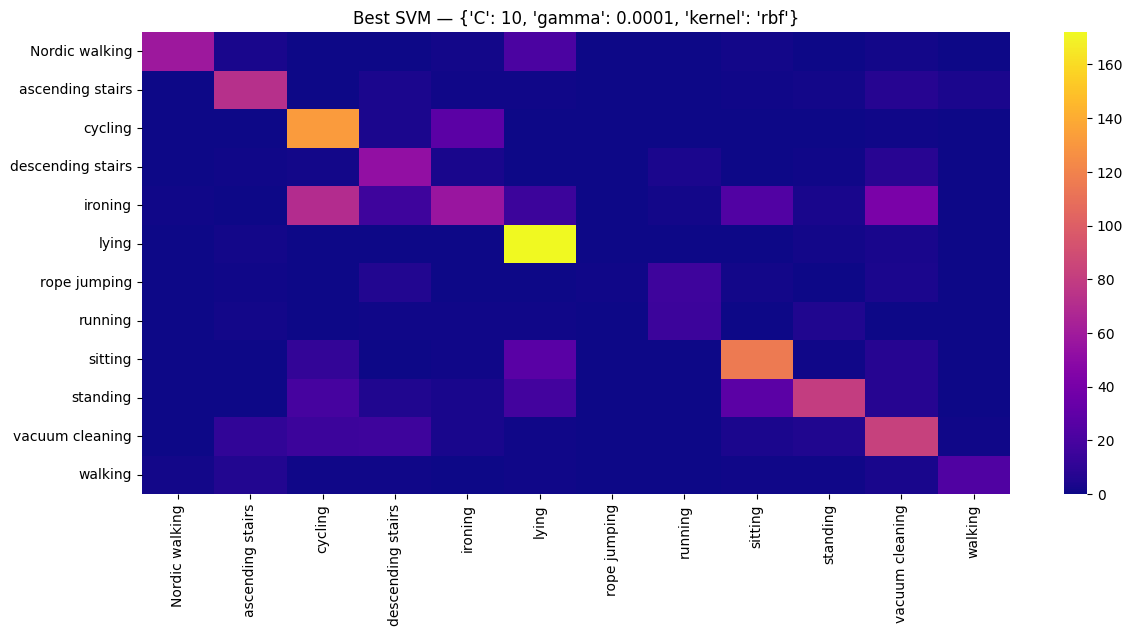

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF params  : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best RF CV score: 0.6875
                   precision    recall  f1-score   support

   Nordic walking       0.75      0.75      0.75        88
 ascending stairs       0.67      0.79      0.73        92
          cycling       0.55      0.87      0.67       165
descending stairs       0.27      0.15      0.19        72
          ironing       0.67      0.64      0.66       228
            lying       0.77      0.96      0.85       179
     rope jumping       0.00      0.00      0.00        30
          running       1.00      0.56      0.72        25
          sitting       0.74      0.65      0.69       163
         standing       0.91      0.59      0.72       160
  vacuum cleaning       0.54      0.70      0.61       138
          walking       0.00      0.00      0.00        39

         accuracy                           0.67      1379
   

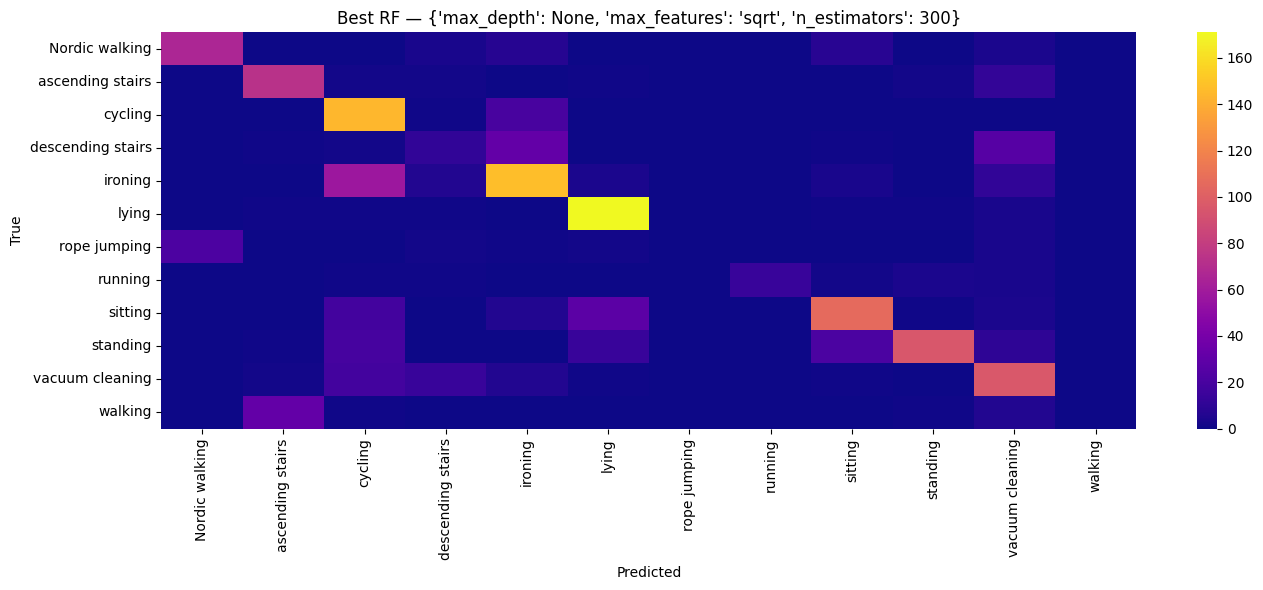

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=config["fine_tune"]["param_grid"],
    cv=config["fine_tune"]["cv"],
    verbose=config["fine_tune"]["verbose"],
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV score   : {grid_search.best_score_:.4f}")

y_pred_best = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

cm_best = pd.DataFrame(confusion_matrix(y_test, y_pred_best),
                       index=class_names, columns=class_names)
plot_heatmap(cm_best)
plt.title(f"Best SVM — {grid_search.best_params_}")
plt.show()

#----------------------------#

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=config["fine_tune_rf"]["param_grid"],
    cv=config["fine_tune_rf"]["cv"],
    verbose=config["fine_tune_rf"]["verbose"],
    n_jobs=config["fine_tune_rf"]["n_jobs"]
)

grid_search_rf.fit(X_train, y_train)
y_pred_best_rf = grid_search_rf.best_estimator_.predict(X_test)

print(f"Best RF params  : {grid_search_rf.best_params_}")
print(f"Best RF CV score: {grid_search_rf.best_score_:.4f}")
print(classification_report(y_test, y_pred_best_rf,
                             target_names=class_names, zero_division=0))

cm_best_rf = pd.DataFrame(confusion_matrix(y_test, y_pred_best_rf),
                          index=class_names, columns=class_names)
plot_heatmap(cm_best_rf)
plt.title(f"Best RF — {grid_search_rf.best_params_}", fontsize=12)
plt.xlabel("Predicted"), plt.ylabel("True")
plt.tight_layout()

plt.show()